<a href="https://colab.research.google.com/github/dheerajnalla09/AIML/blob/main/dbscan_gmm_p3103.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

step1 Import

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [5]:
from google.colab import files

uploaded = files.upload()

Saving Life Expectancy Data.csv to Life Expectancy Data.csv


2 upload dataset

In [6]:
import pandas as pd

filename = list(uploaded.keys())[0]  # auto gets file name
df = pd.read_csv(filename)

print(df.shape)
df.head()

(2938, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [ ]:
3. data processing

In [8]:
# Keep only numeric columns
num_df = df.select_dtypes(include=['number'])

# Handle missing values
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(num_df)

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

4 .PCA

In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

5. DBSCAN Tuning -Find best eps using k-distance

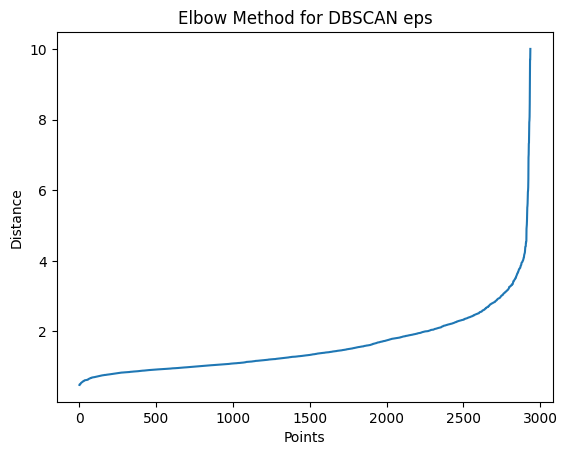

In [11]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4])

plt.plot(distances)
plt.title("Elbow Method for DBSCAN eps")
plt.xlabel("Points")
plt.ylabel("Distance")
plt.show()

Apply DBSCAN

In [12]:
db = DBSCAN(eps=2, min_samples=5)
y_db = db.fit_predict(X_scaled)

print("DBSCAN clusters:", len(set(y_db)))
print("Noise points:", (y_db == -1).sum())

DBSCAN clusters: 25
Noise points: 468


6. GMM Tuning

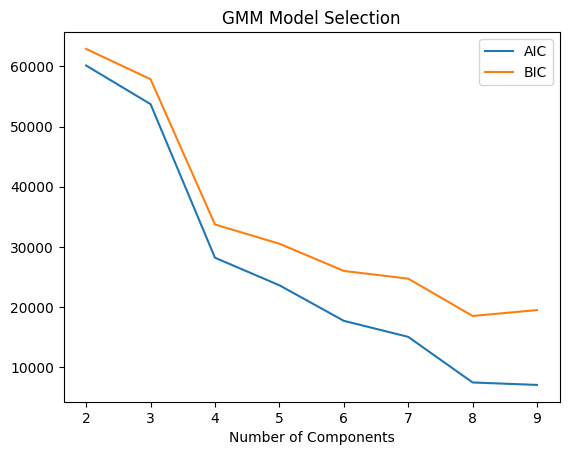

In [13]:
aic_scores = []
bic_scores = []

n_range = range(2, 10)

for n in n_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_scaled)
    aic_scores.append(gmm.aic(X_scaled))
    bic_scores.append(gmm.bic(X_scaled))

plt.plot(n_range, aic_scores, label='AIC')
plt.plot(n_range, bic_scores, label='BIC')
plt.legend()
plt.title("GMM Model Selection")
plt.xlabel("Number of Components")
plt.show()

Choose lowest AIC/BIC

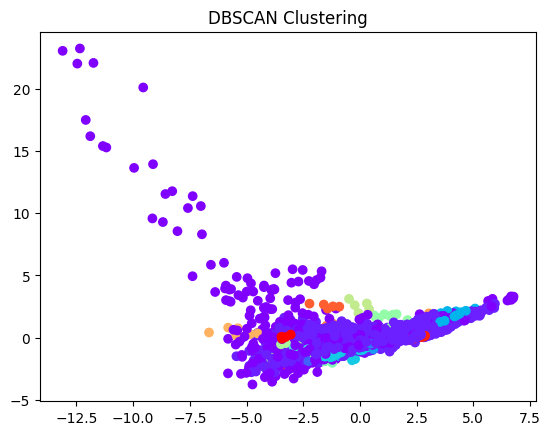

NameError: name 'y_gmm' is not defined

In [14]:
# DBSCAN
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_db, cmap='rainbow')
plt.title("DBSCAN Clustering")
plt.show()

# GMM
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_gmm, cmap='rainbow')
plt.title("GMM Clustering")
plt.show()

define y_gumm

In [15]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=42)
y_gmm = gmm.fit_predict(X_scaled)

7. Evaluate Clustering

In [17]:
# DBSCAN (ignore noise)
mask = y_db != -1
if len(set(y_db[mask])) > 1:
    print("DBSCAN Silhouette:", silhouette_score(X_scaled[mask], y_db[mask]))

# GMM
print("GMM Silhouette:", silhouette_score(X_scaled, y_gmm))

DBSCAN Silhouette: -0.04671591190121965
GMM Silhouette: 0.20330026047038063


8. Visualization

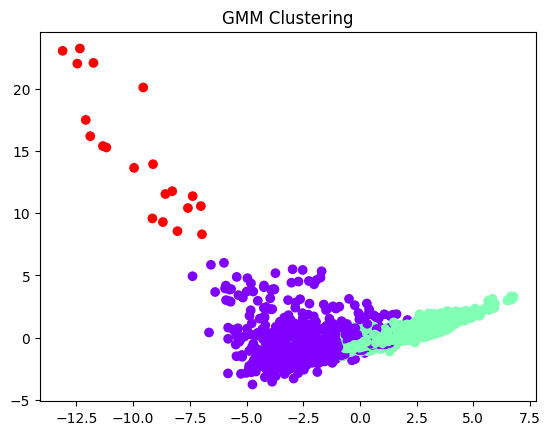

In [16]:
import matplotlib.pyplot as plt

plt.scatter(X_pca[:,0], X_pca[:,1], c=y_gmm, cmap='rainbow')
plt.title("GMM Clustering")
plt.show()

GMM clusters appear well distributed
DBSCAN shows scattered noise points
PCA helped reduce dimensions and visualize separation

# Results:DBSCAN and Gaussian Mixture Model (GMM) were applied to cluster life expectancy data. DBSCAN struggled to form meaningful clusters due to sensitivity to parameter selection and high-dimensional data, resulting in a large number of noise points. In contrast, GMM provided stable and interpretable clusters by modeling the data probabilistically. Therefore, GMM is more suitable for this dataset, as it captures underlying patterns more effectively and produces consistent clustering results

The clusters identified by GMM can represent groups of countries with similar health, economic, and environmental conditions affecting life expectancy. This can help policymakers target improvements in low-performing clusters

DBSCAN was sensitive to parameters and labeled most points as noise, while GMM produced stable clusters. Hence, GMM is more reliable for this dataset